LIBRARIES

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

INPUTS

In [2]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
CLASS_NAMES = ["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [3]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\train",
    labels ='inferred',
    label_mode = 'int',
    image_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = 16
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\val",
    labels ='inferred',
    label_mode = 'int',
    image_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = 16
)
normalize = tf.keras.layers.Rescaling(1./255)
train_dataset= train_dataset.map(lambda x, y: (normalize(x), y))
val_dataset =  val_dataset.map(lambda x, y: (normalize(x), y))

Found 3000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


NETWORK ARCHITECTURE

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    weights = 'imagenet',
    include_top = False, #Remove the ImageNet head
    input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
)

base_model.trainable = False #Freeze base

model = keras.Sequential([
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])

model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ['accuracy']
)

#To visualize the model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,509 (8.66 MB)

 Trainable params: 8,965 (35.02 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

TRAINING

In [10]:
EPOCHS =10
history =  model.fit(
    train_dataset,
    validation_data= val_dataset,
    epochs = EPOCHS
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 189ms/step - accuracy: 0.7157 - loss: 0.8103 - val_accuracy: 0.8460 - val_loss: 0.4342
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 35s 186ms/step - accuracy: 0.8493 - loss: 0.4345 - val_accuracy: 0.8680 - val_loss: 0.3774
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 37s 194ms/step - accuracy: 0.8687 - loss: 0.3721 - val_accuracy: 0.8680 - val_loss: 0.3717
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 207ms/step - accuracy: 0.8913 - loss: 0.3139 - val_accuracy: 0.8760 - val_loss: 0.3530
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 38s 204ms/step - accuracy: 0.9150 - loss: 0.2550 - val_accuracy: 0.8840 - val_loss: 0.3469
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 207ms/step - accuracy: 0.9183 - loss: 0.2400 - val_accuracy: 0.8830 - val_loss: 0.3521
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 220ms/step - accuracy: 0.9187 - loss: 0.2148 - val_accuracy: 0.8790 - val_loss: 0.3464
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 38s 201ms/step - accuracy: 0.9260 - loss: 0

PLOTTING

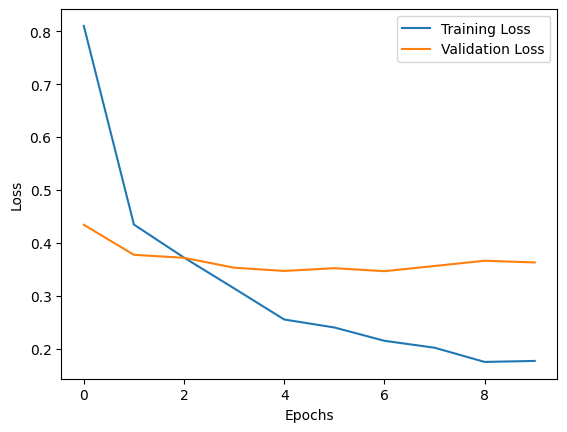

In [12]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

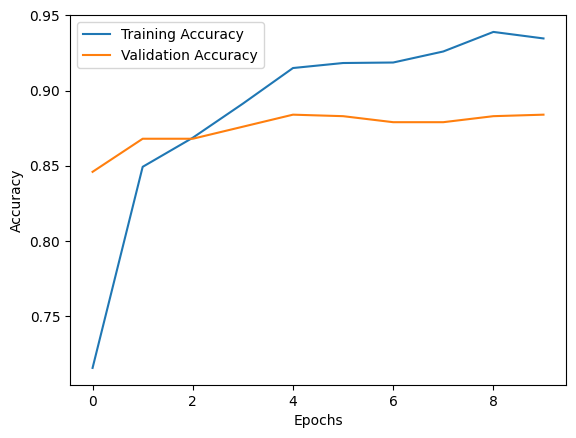

In [13]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()